# EDA: Population Change and Density (Table 1.1)

Loads from DuckDB. No raw file access here.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt

%matplotlib inline

sys.path.append(str(Path.cwd().parent.parent if Path.cwd().name == "eda" else Path.cwd()))

from config.project_paths import DB_FILES, FIGURES

DB_PATH = DB_FILES / "aruba.duckdb"
TABLE   = "population_change_density"

print("DB :", DB_PATH)
print("FIG:", FIGURES)

INFO:config.project_paths:Ensured directory exists: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/data/raw
INFO:config.project_paths:Ensured directory exists: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/data/processed
INFO:config.project_paths:Ensured directory exists: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/data/external
INFO:config.project_paths:Ensured directory exists: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/logs
INFO:config.project_paths:Ensured directory exists: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/figures
INFO:config.project_paths:Ensured directory exists: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/db_files


DB : /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/db_files/aruba.duckdb
FIG: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/figures


In [2]:
con = duckdb.connect(str(DB_PATH))
df = con.execute(f"SELECT * FROM {TABLE} ORDER BY year").df()
con.close()

print(df.shape)
df

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


(9, 7)


,year,population_female,population_male,annual_change_pct,density_per_km2,males_per_1000_females,population_total
0,2015,57326.2,51309.2,1.35,603.5,895.0,108635.4
1,2016,57356.8,51461.6,0.17,604.5,897.2,108818.3
2,2017,57252.7,51398.6,-0.15,603.6,897.7,108651.3
3,2018,57652.0,51512.0,0.47,606.5,893.4,109164.0
4,2019,57726.1,51515.1,0.07,606.9,892.4,109241.2
5,2020,57002.0,50930.3,-1.21,599.6,893.4,107932.0
6,2021,56804.1,50664.3,-0.43,597.0,891.9,107468.4
7,2022,56712.0,50440.2,-0.29,595.3,889.4,107152.3
8,2023,57007.3,50559.0,0.39,597.6,887.0,107566.3


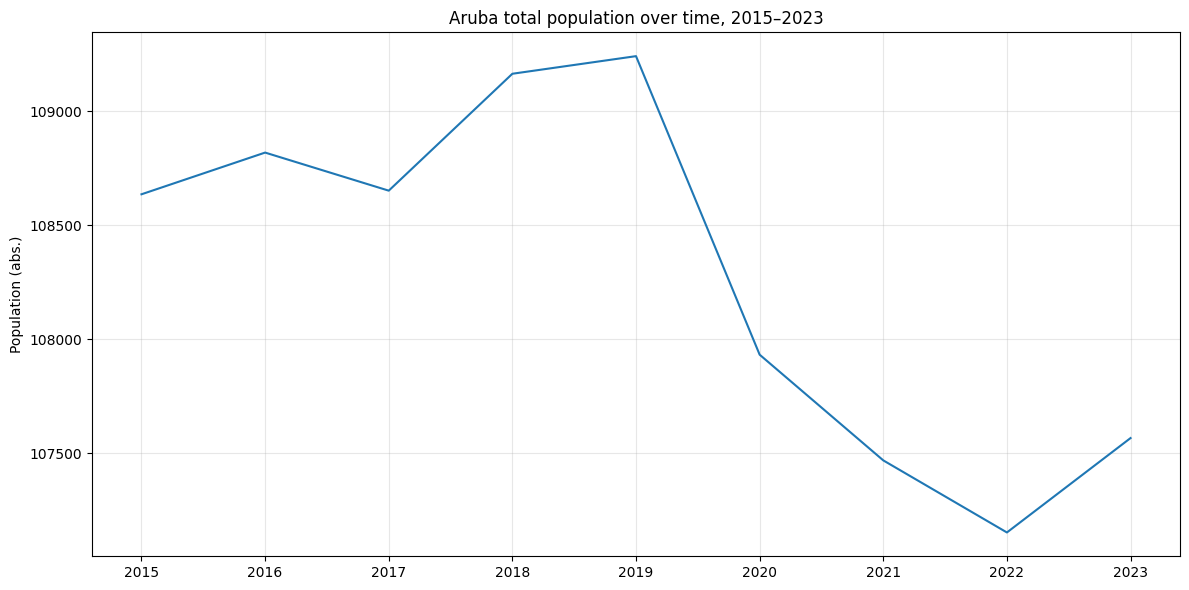

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df["year"], df["population_total"])
plt.title("Aruba total population over time, 2015–2023")
plt.ylabel("Population (abs.)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "aruba_total_population_2015_2023.png", dpi=300)
plt.show()

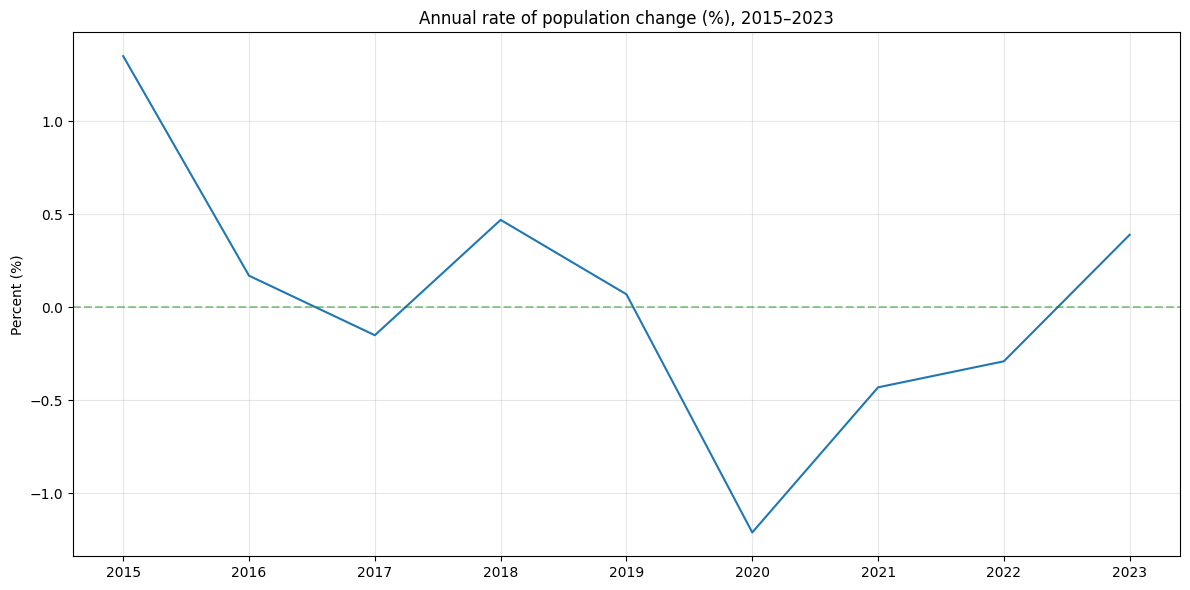

In [4]:
# Annual rate of population change

plt.figure(figsize=(12, 6))
plt.plot(df["year"], df["annual_change_pct"])
plt.axhline(0, linestyle="--", color="green", alpha=0.4)
plt.title("Annual rate of population change (%), 2015–2023")
plt.ylabel("Percent (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "annual_population_change_rate_2015_2023.png", dpi=300)
plt.show()

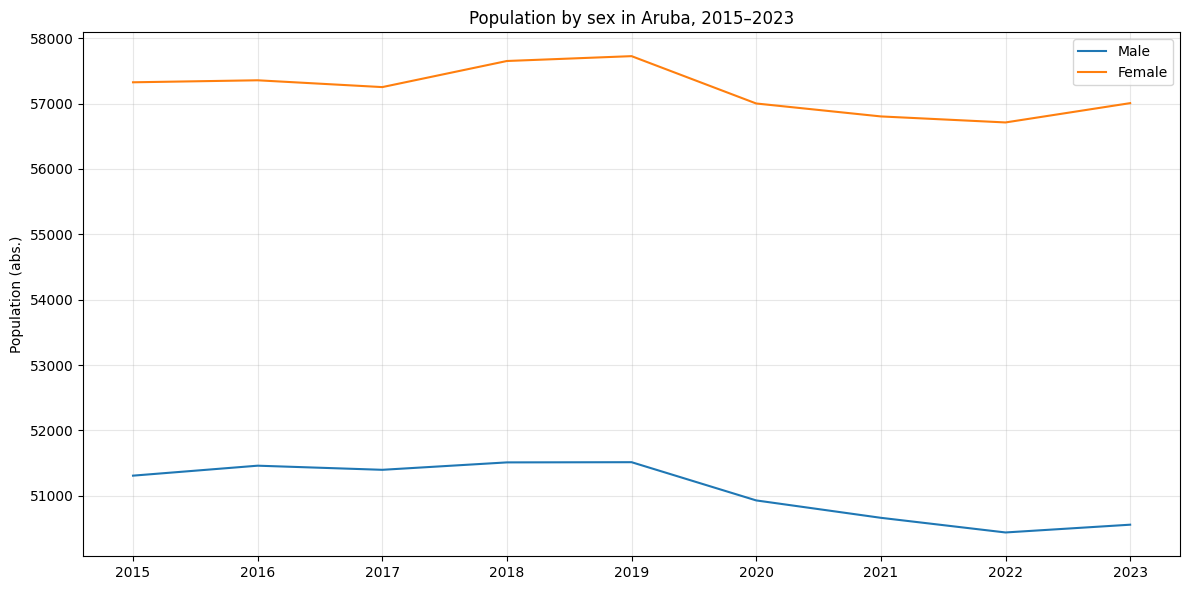

In [5]:
# Population by sex

plt.figure(figsize=(12, 6))
plt.plot(df["year"], df["population_male"],   label="Male")
plt.plot(df["year"], df["population_female"], label="Female")
plt.title("Population by sex in Aruba, 2015–2023")
plt.ylabel("Population (abs.)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "yoy_population_change_by_sex_2016_2023.png", dpi=300)
plt.show()

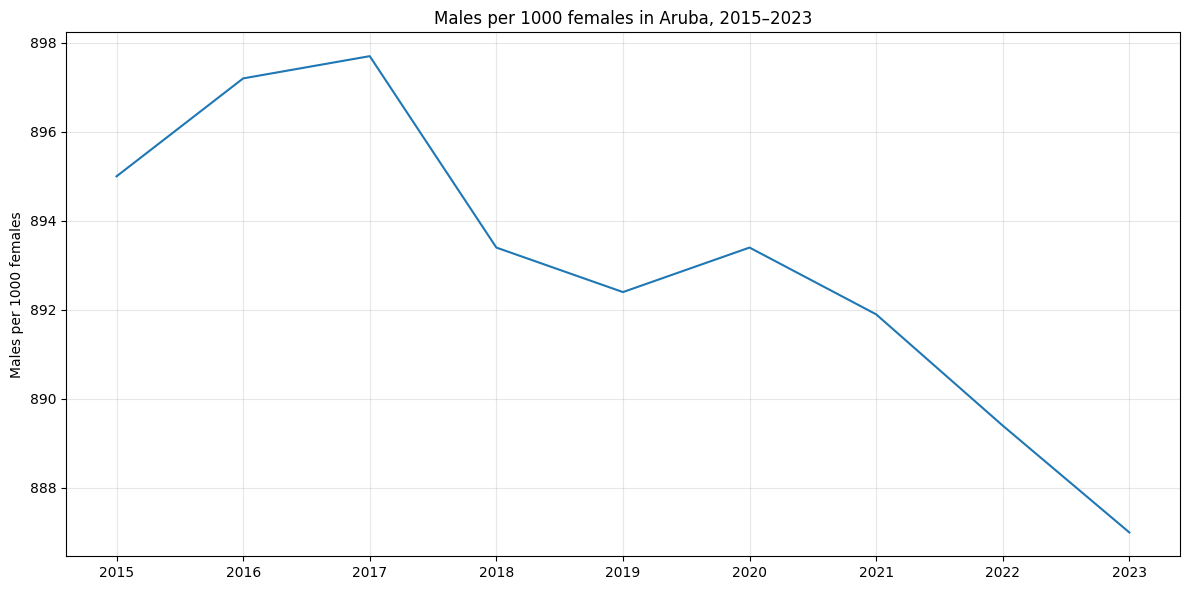

In [6]:
# Males per 1000 females

plt.figure(figsize=(12, 6))
plt.plot(df["year"], df["males_per_1000_females"])
plt.title("Males per 1000 females in Aruba, 2015–2023")
plt.ylabel("Males per 1000 females")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "males_per_1000_females.png", dpi=300)
plt.show()